In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from transformers import pipeline
from datetime import datetime, timedelta

sns.set_theme(style="darkgrid")
print("Libraries loaded!")


Libraries loaded!


In [2]:
# Load a pre-trained financial sentiment model from HuggingFace
# This downloads automatically the first time (~500MB, may take a few mins)
sentiment_model = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

print("FinBERT model loaded!")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

C:\Users\atulp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\atulp\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT model loaded!


In [3]:
# Real-world style financial headlines
headlines = [
    {"date": "2024-01-15", "ticker": "AAPL", "headline": "Apple reports record quarterly revenue driven by iPhone sales"},
    {"date": "2024-01-15", "ticker": "AAPL", "headline": "Apple faces antitrust investigation in European Union"},
    {"date": "2024-01-16", "ticker": "TSLA", "headline": "Tesla misses delivery targets for third consecutive quarter"},
    {"date": "2024-01-16", "ticker": "TSLA", "headline": "Tesla announces breakthrough in battery technology"},
    {"date": "2024-01-17", "ticker": "MSFT", "headline": "Microsoft Azure cloud revenue surges 28 percent year over year"},
    {"date": "2024-01-17", "ticker": "MSFT", "headline": "Microsoft faces regulatory scrutiny over Activision deal"},
    {"date": "2024-01-18", "ticker": "AAPL", "headline": "Apple stock downgraded by Goldman Sachs amid weak demand"},
    {"date": "2024-01-18", "ticker": "TSLA", "headline": "Tesla expands into new markets with aggressive pricing strategy"},
    {"date": "2024-01-19", "ticker": "MSFT", "headline": "Microsoft AI investments show strong early returns"},
    {"date": "2024-01-19", "ticker": "AAPL", "headline": "Apple launches new product line exceeding analyst expectations"},
]

df_headlines = pd.DataFrame(headlines)
print(df_headlines)

         date ticker                                           headline
0  2024-01-15   AAPL  Apple reports record quarterly revenue driven ...
1  2024-01-15   AAPL  Apple faces antitrust investigation in Europea...
2  2024-01-16   TSLA  Tesla misses delivery targets for third consec...
3  2024-01-16   TSLA  Tesla announces breakthrough in battery techno...
4  2024-01-17   MSFT  Microsoft Azure cloud revenue surges 28 percen...
5  2024-01-17   MSFT  Microsoft faces regulatory scrutiny over Activ...
6  2024-01-18   AAPL  Apple stock downgraded by Goldman Sachs amid w...
7  2024-01-18   TSLA  Tesla expands into new markets with aggressive...
8  2024-01-19   MSFT  Microsoft AI investments show strong early ret...
9  2024-01-19   AAPL  Apple launches new product line exceeding anal...


In [4]:
# Analyse each headline
results = []

for _, row in df_headlines.iterrows():
    result = sentiment_model(row["headline"])[0]
    results.append({
        "date": row["date"],
        "ticker": row["ticker"],
        "headline": row["headline"],
        "sentiment": result["label"],
        "confidence": round(result["score"], 4)
    })

df_results = pd.DataFrame(results)
print(df_results[["ticker", "sentiment", "confidence", "headline"]])

  ticker sentiment  confidence  \
0   AAPL  positive      0.9119   
1   AAPL  negative      0.8885   
2   TSLA  negative      0.9510   
3   TSLA  positive      0.6039   
4   MSFT  positive      0.9444   
5   MSFT  negative      0.9453   
6   AAPL  negative      0.9641   
7   TSLA  positive      0.8948   
8   MSFT  positive      0.9532   
9   AAPL  positive      0.9429   

                                            headline  
0  Apple reports record quarterly revenue driven ...  
1  Apple faces antitrust investigation in Europea...  
2  Tesla misses delivery targets for third consec...  
3  Tesla announces breakthrough in battery techno...  
4  Microsoft Azure cloud revenue surges 28 percen...  
5  Microsoft faces regulatory scrutiny over Activ...  
6  Apple stock downgraded by Goldman Sachs amid w...  
7  Tesla expands into new markets with aggressive...  
8  Microsoft AI investments show strong early ret...  
9  Apple launches new product line exceeding anal...  


<Figure size 1000x500 with 0 Axes>

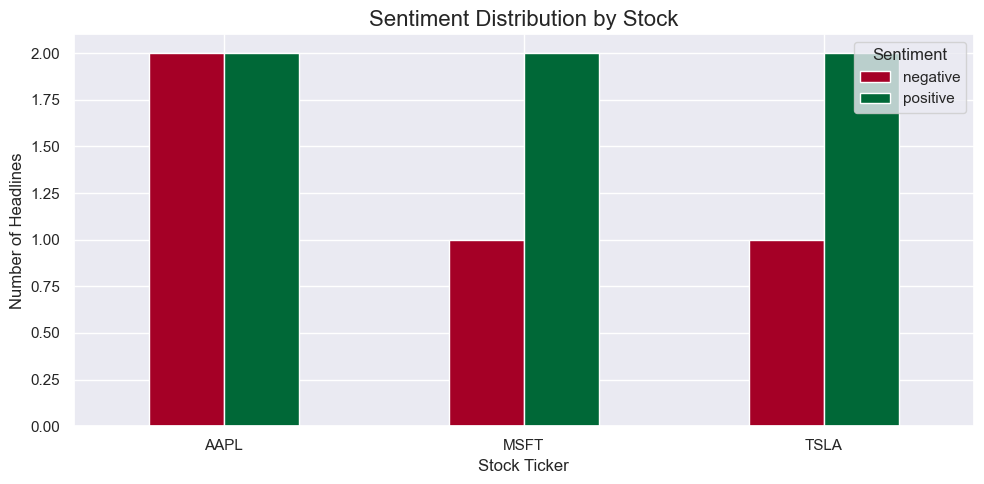

In [5]:
plt.figure(figsize=(10, 5))

# Count sentiments per ticker
sentiment_counts = df_results.groupby(["ticker", "sentiment"]).size().unstack(fill_value=0)
sentiment_counts.plot(kind="bar", figsize=(10, 5), colormap="RdYlGn")

plt.title("Sentiment Distribution by Stock", fontsize=16)
plt.xlabel("Stock Ticker")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("../images/sentiment_distribution.png")
plt.show()

In [6]:
tickers = ["AAPL", "TSLA", "MSFT"]

stock_data = yf.download(tickers, start="2024-01-15", end="2024-01-20")["Close"]
stock_data = stock_data.reset_index()
stock_data["Date"] = pd.to_datetime(stock_data["Date"]).dt.strftime("%Y-%m-%d")

print(stock_data)

[*********************100%***********************]  3 of 3 completed

Ticker        Date        AAPL        MSFT        TSLA
0       2024-01-16  181.741974  383.660980  219.910004
1       2024-01-17  180.801727  382.874481  215.550003
2       2024-01-18  186.690552  387.200012  211.880005
3       2024-01-19  189.590439  391.918671  212.190002


In [7]:
# Average confidence score per ticker per day (positive = high, negative = low)
df_results["score"] = df_results.apply(
    lambda x: x["confidence"] if x["sentiment"] == "positive"
    else -x["confidence"] if x["sentiment"] == "negative"
    else 0, axis=1
)

daily_sentiment = df_results.groupby(["date", "ticker"])["score"].mean().reset_index()
daily_sentiment.columns = ["Date", "Ticker", "Sentiment Score"]

print(daily_sentiment)

         Date Ticker  Sentiment Score
0  2024-01-15   AAPL          0.01170
1  2024-01-16   TSLA         -0.17355
2  2024-01-17   MSFT         -0.00045
3  2024-01-18   AAPL         -0.96410
4  2024-01-18   TSLA          0.89480
5  2024-01-19   AAPL          0.94290
6  2024-01-19   MSFT          0.95320


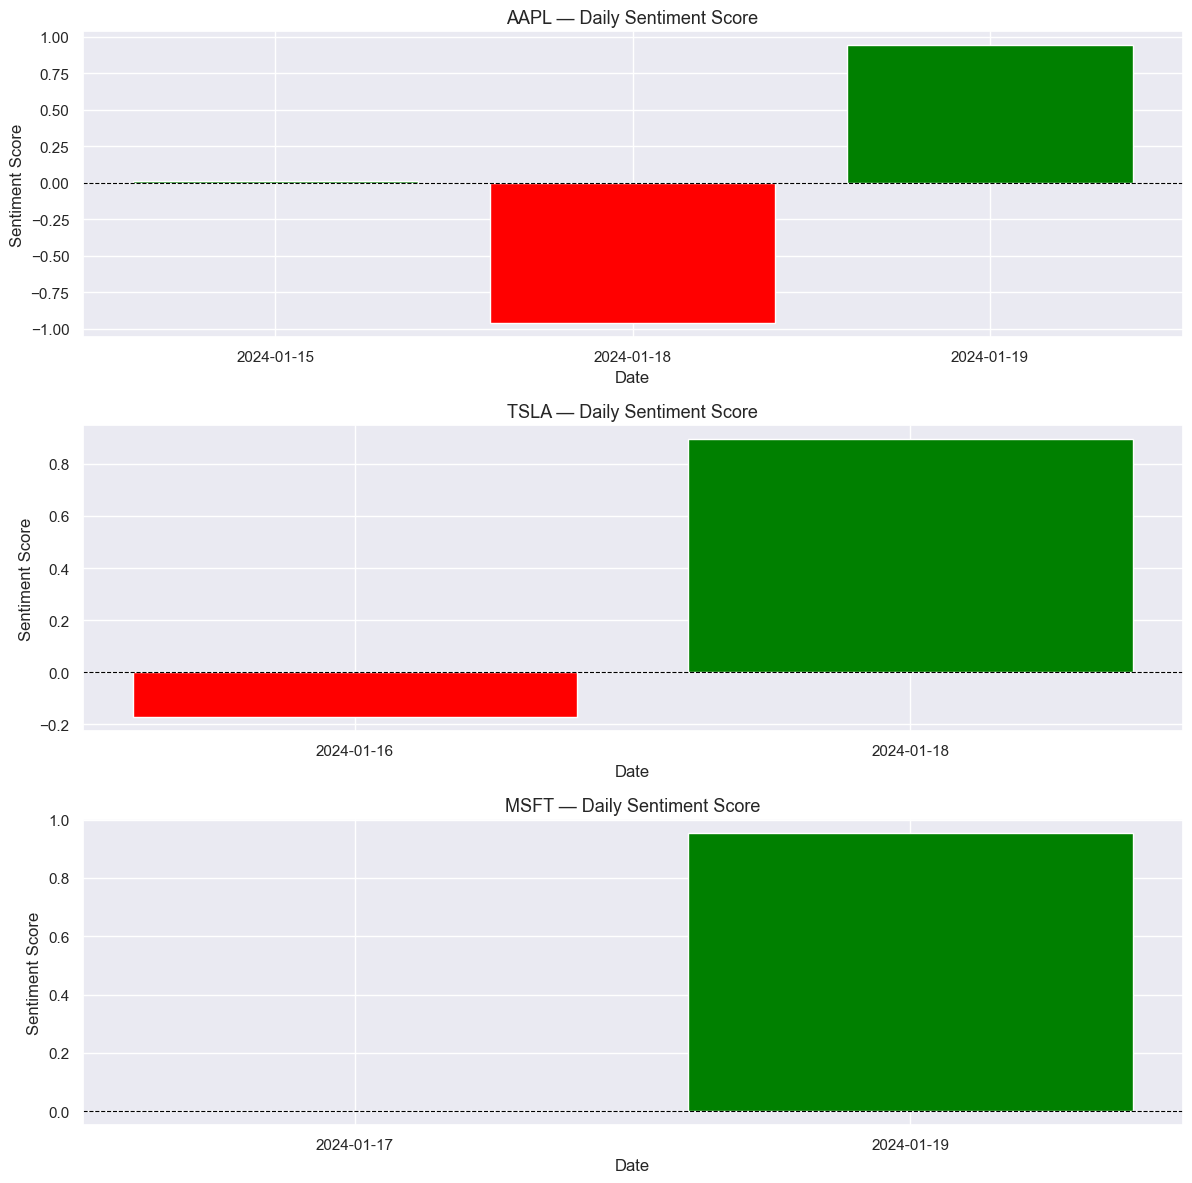

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, ticker in zip(axes, ["AAPL", "TSLA", "MSFT"]):
    ticker_data = daily_sentiment[daily_sentiment["Ticker"] == ticker]
    colors = ["green" if s > 0 else "red" for s in ticker_data["Sentiment Score"]]
    ax.bar(ticker_data["Date"], ticker_data["Sentiment Score"], color=colors)
    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{ticker} — Daily Sentiment Score", fontsize=13)
    ax.set_ylabel("Sentiment Score")
    ax.set_xlabel("Date")

plt.tight_layout()
plt.savefig("../images/sentiment_over_time.png")
plt.show()

In [9]:
df_results.to_csv("../data/sentiment_results.csv", index=False)
print("Results saved!")

Results saved!
